# Seoul Metropolitan Area · 2023 LivePOP Hourly Heatmap

## Purpose
Visualize the **average hourly population by 행정동 (administrative dong)** across the Seoul metropolitan area for the full year 2023.
We produce 24 frames (00:00 ~ 23:00) on a shared color scale plus a single animated GIF.

## Inputs
- `../data/raw/livepop_sudogwon_2023*.parquet` — 12 monthly files (one per month), schema:
  `date(Int32 yyyymmdd), hour(Int8), admdong_cd(String), admdong_nm(String), age_10(Int8), pop(Float64)`
- `../data/mapping/sudogwon_admdong_polygons.parquet` — 1,155 행정동 polygons in **EPSG:5179** (KGD2002 / Unified CS)

## Outputs
- `../data/viz/heatmap_2023/hour_HH.png` × 24 + `heatmap_2023.gif` (absolute population)
- `../outputs/heatmap_2023_density/heatmap_density_h{HH}.png` × 24 + `heatmap_24h_density.gif`
- `../outputs/heatmap_2023_comparison/comparison_12h.png` (absolute vs density side-by-side)

## Data Caveats
- Source: KT mobile-signaling-derived LivePOP. **Not a census** — under-counts age groups with low phone ownership (very young / very elderly), domestic SIM only.
- Counts represent KT-estimated presence; absolute values should be read as proxies, not exact head counts.
- ~159 KT 행정동 codes (12%) lack a polygon (KT mapping snapshot 2025-12 vs. polygon snapshot 2026-02). Those rows are dropped at the join step.

In [8]:
from pathlib import Path

import geopandas as gpd
import imageio.v3 as iio
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from matplotlib.cm import ScalarMappable
from matplotlib.colors import LogNorm
from matplotlib.ticker import FuncFormatter, LogLocator

PROJECT = Path.cwd().parent
DATA_DIR = PROJECT / "data" / "raw"
MAPPING_DIR = PROJECT / "data" / "mapping"
OUT_DIR = PROJECT / "data" / "viz" / "heatmap_2023"
OUT_DIR_DENSITY = PROJECT / "outputs" / "heatmap_2023_density"
OUT_DIR_CMP = PROJECT / "outputs" / "heatmap_2023_comparison"
for d in (OUT_DIR, OUT_DIR_DENSITY, OUT_DIR_CMP):
    d.mkdir(parents=True, exist_ok=True)

print("DATA_DIR:        ", DATA_DIR)
print("MAPPING_DIR:     ", MAPPING_DIR)
print("OUT_DIR:         ", OUT_DIR)
print("OUT_DIR_DENSITY: ", OUT_DIR_DENSITY)
print("OUT_DIR_CMP:     ", OUT_DIR_CMP)

DATA_DIR:         /Users/hwcho/Documents/python/NIMS/KT_data/data/raw
MAPPING_DIR:      /Users/hwcho/Documents/python/NIMS/KT_data/data/mapping
OUT_DIR:          /Users/hwcho/Documents/python/NIMS/KT_data/data/viz/heatmap_2023
OUT_DIR_DENSITY:  /Users/hwcho/Documents/python/NIMS/KT_data/outputs/heatmap_2023_density
OUT_DIR_CMP:      /Users/hwcho/Documents/python/NIMS/KT_data/outputs/heatmap_2023_comparison


## 1. Load and aggregate

Strategy — for each `(hour, admdong_cd)` over the full year 2023:
1. Stream-scan all 12 monthly parquets via `pl.scan_parquet` (lazy, no full materialization).
2. Sum across `age_10` (collapse age groups) to get population per `(date, hour, admdong_cd)`.
3. Average across all 365 days to get one value per `(hour, admdong_cd)`.

Output: 24 hours × ~1,149 행정동 ≈ 27,600 rows.

In [9]:
lf = pl.scan_parquet(str(DATA_DIR / "livepop_sudogwon_2023*.parquet"))

by_day = (
    lf.group_by(["date", "hour", "admdong_cd"])
    .agg(pl.col("pop").sum().alias("pop_day"))
)
hourly = (
    by_day.group_by(["hour", "admdong_cd"])
    .agg(pl.col("pop_day").mean().alias("pop_avg"))
    .sort(["hour", "admdong_cd"])
    .collect(engine="streaming")
)

print("rows:", hourly.height)
print("unique hours:", hourly.select("hour").n_unique())
print("unique admdong:", hourly.select("admdong_cd").n_unique())
print("pop_avg range:", hourly["pop_avg"].min(), "~", hourly["pop_avg"].max())
hourly.head(5)

rows: 27720
unique hours: 24
unique admdong: 1155
pop_avg range: 550.3462465753425 ~ 133118.92282191766


hour,admdong_cd,pop_avg
i8,str,f64
0,"""11110515""",10295.54
0,"""11110530""",9123.36063
0,"""11110540""",2386.361863
0,"""11110550""",9076.103397
0,"""11110560""",15043.528301


## 2. Color scale (shared across all 24 frames)

**Why log scale?** Dong populations span ~3 orders of magnitude (uninhabited industrial zones ~10² to dense residential ~10⁵). On a linear scale the densest few dongs saturate the colormap and everything else looks identical.

**Why percentile clipping (5–99)?** The very smallest and very largest values are outliers (parks, large institutions). Clipping the long tails compresses the dynamic range so mid-range variation stays readable.

We compute one global `vmin/vmax` from all (hour, dong) values so that every hourly frame uses the **same scale** — visual comparisons across hours are then meaningful.

vmin (5pct): 4,459.8
vmax (99pct): 70,418.2


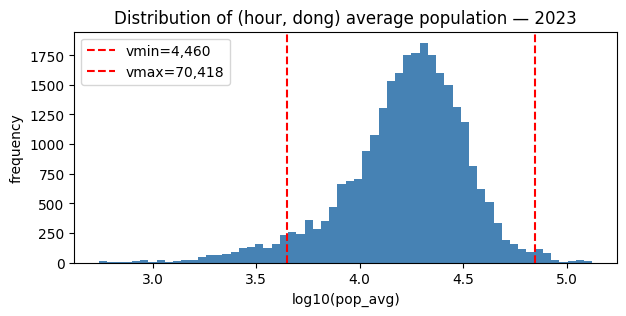

In [10]:
pop_values = hourly["pop_avg"].to_numpy()
pop_pos = pop_values[pop_values > 0]

vmin = float(np.percentile(pop_pos, 5))
vmax = float(np.percentile(pop_pos, 99))
print(f"vmin (5pct): {vmin:,.1f}")
print(f"vmax (99pct): {vmax:,.1f}")

fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(np.log10(pop_pos), bins=60, color="steelblue")
ax.axvline(np.log10(vmin), color="red", ls="--", label=f"vmin={vmin:,.0f}")
ax.axvline(np.log10(vmax), color="red", ls="--", label=f"vmax={vmax:,.0f}")
ax.set_xlabel("log10(pop_avg)")
ax.set_ylabel("frequency")
ax.set_title("Distribution of (hour, dong) average population — 2023")
ax.legend()
plt.show()

## 3. Visualization function

Reusable function that draws a single hour. Design choices:
- **Colormap:** `viridis` (perceptually uniform, color-blind friendly).
- **Norm:** `LogNorm(vmin, vmax)` with values clipped to vmax.
- **Colorbar:** dense log ticks — majors at powers of 10 (with comma-grouped labels), minors at 2/3/5/7 of each decade (smaller font). Gives readable scale without losing detail.
- **Labels:** English only (avoids macOS/Linux Korean font issues).
- **Hour badge:** large `HH:00` in the upper-left so the time is obvious in the GIF.
- **No axes ticks:** map is the message; bounding box is implicit.

In [11]:
polygons = gpd.read_parquet(MAPPING_DIR / "sudogwon_admdong_polygons.parquet")
print("polygons:", len(polygons), "CRS:", polygons.crs.to_epsg())

hourly_pd = hourly.to_pandas()


def _format_log(x, pos):
    if x >= 1:
        return f"{int(round(x)):,}"
    return f"{x:.1f}"


_fmt = FuncFormatter(_format_log)


def attach_dense_log_colorbar(ax, norm, cmap="viridis", label="Population (log scale)"):
    """Attach a log colorbar with major + minor ticks, labeled at both levels."""
    sm = ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, shrink=0.8, label=label)
    cbar.ax.yaxis.set_major_locator(LogLocator(base=10, numticks=20))
    cbar.ax.yaxis.set_minor_locator(LogLocator(base=10, subs=(2, 3, 5, 7), numticks=50))
    cbar.ax.yaxis.set_major_formatter(_fmt)
    cbar.ax.yaxis.set_minor_formatter(_fmt)
    cbar.ax.tick_params(which="major", labelsize=10)
    cbar.ax.tick_params(which="minor", labelsize=7)
    return cbar


def plot_hour(hour: int, ax=None, show_colorbar: bool = True):
    """Draw an absolute-population heatmap for a single hour."""
    snap = hourly_pd[hourly_pd["hour"] == hour][["admdong_cd", "pop_avg"]]
    gdf = polygons.merge(snap, on="admdong_cd", how="left")

    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(10, 11))

    norm = LogNorm(vmin=vmin, vmax=vmax, clip=True)
    gdf.plot(
        column="pop_avg",
        ax=ax,
        cmap="viridis",
        norm=norm,
        edgecolor="white",
        linewidth=0.15,
        missing_kwds={"color": "lightgrey", "label": "no data"},
        legend=False,
    )
    if show_colorbar:
        attach_dense_log_colorbar(ax, norm, label="Population (log scale)")
    ax.set_axis_off()
    ax.set_title("Seoul Metropolitan Area · LivePOP 2023 average", fontsize=12)
    ax.text(
        0.02,
        0.97,
        f"{hour:02d}:00",
        transform=ax.transAxes,
        fontsize=36,
        fontweight="bold",
        va="top",
        color="black",
        bbox={"facecolor": "white", "alpha": 0.7, "pad": 6, "edgecolor": "none"},
    )
    if standalone:
        return fig, ax
    return ax

polygons: 1155 CRS: 5179


## 4. Sanity test — render hour 12 only

Single-frame test to validate the rendering before committing to all 24 PNGs.

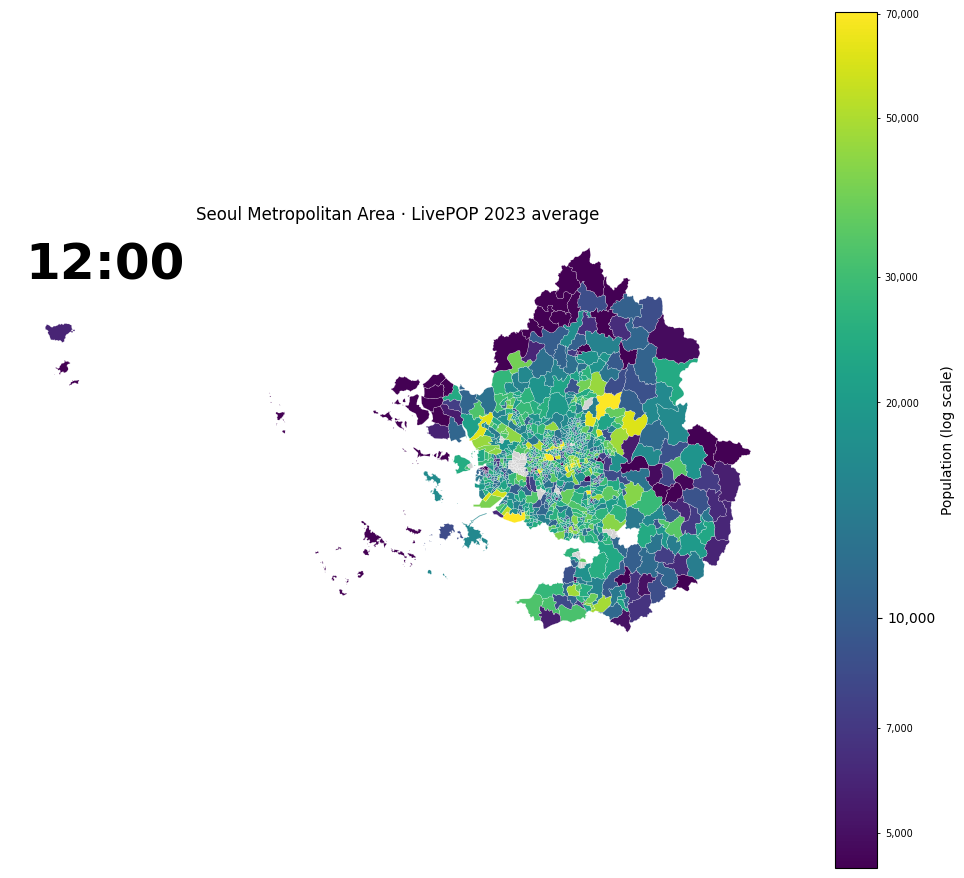

In [12]:
fig, ax = plot_hour(12)
plt.tight_layout()
plt.show()

## 5. Generate all 24 frames

Save 24 PNGs at 120 dpi. Use `bbox_inches='tight'` so the saved frames have minimal whitespace but identical extents (LogNorm + shared vmin/vmax keeps colors consistent).

In [14]:
for h in range(24):
    fig, ax = plot_hour(h)
    out = OUT_DIR / f"hour_{h:02d}.png"
    fig.savefig(out, dpi=120, bbox_inches="tight")
    plt.close(fig)
    print(f"saved {out.name}")

saved hour_00.png
saved hour_01.png
saved hour_02.png
saved hour_03.png
saved hour_04.png
saved hour_05.png
saved hour_06.png
saved hour_07.png
saved hour_08.png
saved hour_09.png
saved hour_10.png
saved hour_11.png
saved hour_12.png
saved hour_13.png
saved hour_14.png
saved hour_15.png
saved hour_16.png
saved hour_17.png
saved hour_18.png
saved hour_19.png
saved hour_20.png
saved hour_21.png
saved hour_22.png
saved hour_23.png


## 6. Animated GIF

Stitch the 24 PNGs into a GIF at 2 fps (500 ms per frame) so the day-cycle is comfortable to watch.

In [15]:
frame_paths = sorted(OUT_DIR.glob("hour_*.png"))
frames = [iio.imread(p) for p in frame_paths]
gif_path = OUT_DIR / "heatmap_2023.gif"
iio.imwrite(gif_path, frames, duration=500, loop=0)
print("wrote", gif_path, f"({gif_path.stat().st_size / 1024:.0f} KB)")

wrote /Users/hwcho/Documents/python/NIMS/KT_data/data/viz/heatmap_2023/heatmap_2023.gif (710 KB)


## 7. Results & next steps

Expected reading of the day-cycle (sanity check):
- **02:00–05:00** — residential dongs peak (everyone at home).
- **09:00–11:00** — central business / office dongs swell (Gangnam, CBD).
- **18:00–20:00** — commuters thin out from office cores and bloom back into residential rings.
- Recreational dongs (e.g. Han River parks, large commercial belts) may show their own evening/weekend signatures — visible in monthly or weekday-split breakdowns rather than this overall mean.

Possible follow-ups:
- Weekday vs. weekend split — should reshape the commute peaks.
- Age-segmented panels (0–19 / 20–64 / 65+) — children at home, workers in offices, elderly stable.
- Difference map between 03:00 and 14:00 to visualize the commute amplitude per dong.
- Annual time-series for selected dongs to spot anomalies (COVID dip, holidays).

## 인구밀도 (density) 버전

Why a separate density view?
- Absolute population maps make **large-area dongs** (가평군, 양평군, etc.) look dark/saturated just because they cover more land — not because residents are denser.
- Dividing by 행정동 area (km²) reveals where people are actually **packed** vs. spread out.
- Comparing both views answers two different questions: *"where are the most people?"* (absolute) vs. *"where is the city most intense?"* (density).

In [16]:
polygons_area = polygons.copy()
polygons_area["area_km2"] = polygons_area.geometry.area / 1_000_000  # EPSG:5179 is in metres

print("area_km2 distribution (km²):")
print(f"  min:    {polygons_area['area_km2'].min():.3f}")
print(f"  median: {polygons_area['area_km2'].median():.3f}")
print(f"  max:    {polygons_area['area_km2'].max():.3f}")

hourly_density = hourly_pd.merge(
    polygons_area[["admdong_cd", "area_km2"]], on="admdong_cd", how="inner"
)
hourly_density["density"] = hourly_density["pop_avg"] / hourly_density["area_km2"]

print("\ndensity distribution (people/km²):")
qs = hourly_density["density"].quantile([0.0, 0.05, 0.5, 0.95, 0.99, 1.0]).to_dict()
for q, v in qs.items():
    print(f"  q{q:.2f}: {v:,.1f}")
print(f"  rows: {len(hourly_density):,}")

area_km2 distribution (km²):
  min:    0.174
  median: 1.666
  max:    230.682

density distribution (people/km²):
  q0.00: 6.5
  q0.05: 118.8
  q0.50: 10,951.4
  q0.95: 32,541.9
  q0.99: 41,573.0
  q1.00: 72,454.4
  rows: 26,424


### 밀도용 색상 스케일

Density values run from <1 person/km² (mountainous outer 군) to tens of thousands/km² (dense Seoul cores). Same log + percentile-clipping approach as the absolute map keeps both maps comparable in **technique** while letting their **scales** differ.

vmin_d (5pct):  118.84 / km²
vmax_d (99pct): 41,573.00 / km²


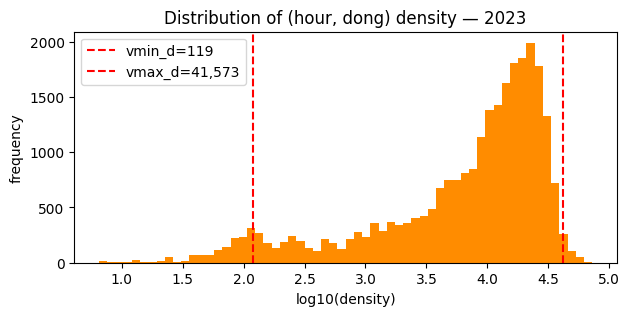

In [17]:
den_values = hourly_density["density"].to_numpy()
den_pos = den_values[den_values > 0]

vmin_d = float(np.percentile(den_pos, 5))
vmax_d = float(np.percentile(den_pos, 99))
print(f"vmin_d (5pct):  {vmin_d:,.2f} / km²")
print(f"vmax_d (99pct): {vmax_d:,.2f} / km²")

fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(np.log10(den_pos), bins=60, color="darkorange")
ax.axvline(np.log10(vmin_d), color="red", ls="--", label=f"vmin_d={vmin_d:,.0f}")
ax.axvline(np.log10(vmax_d), color="red", ls="--", label=f"vmax_d={vmax_d:,.0f}")
ax.set_xlabel("log10(density)")
ax.set_ylabel("frequency")
ax.set_title("Distribution of (hour, dong) density — 2023")
ax.legend()
plt.show()

### plot 함수 (밀도 버전)

Same design as `plot_hour`, but the column drawn is `density` and the color scale uses `vmin_d / vmax_d`.

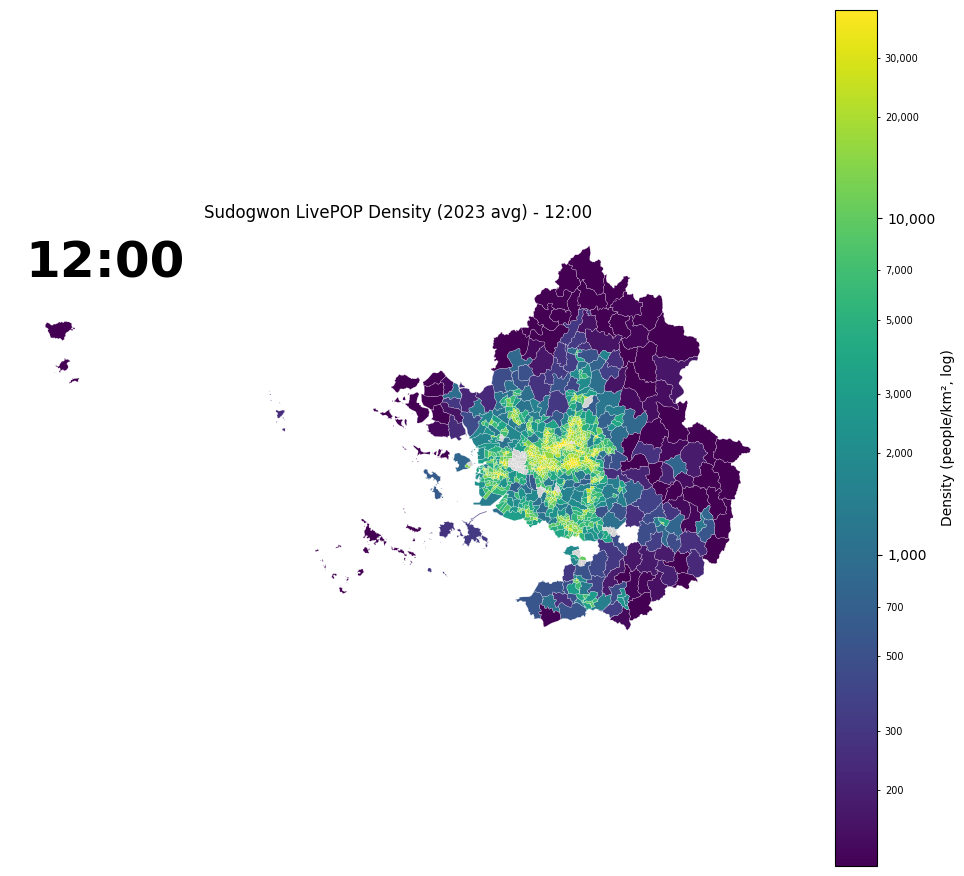

In [18]:
def plot_hour_density(hour: int, ax=None, show_colorbar: bool = True):
    """Draw a density (people/km²) heatmap for a single hour."""
    snap = hourly_density[hourly_density["hour"] == hour][["admdong_cd", "density"]]
    gdf = polygons.merge(snap, on="admdong_cd", how="left")

    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(10, 11))

    norm = LogNorm(vmin=vmin_d, vmax=vmax_d, clip=True)
    gdf.plot(
        column="density",
        ax=ax,
        cmap="viridis",
        norm=norm,
        edgecolor="white",
        linewidth=0.15,
        missing_kwds={"color": "lightgrey", "label": "no data"},
        legend=False,
    )
    if show_colorbar:
        attach_dense_log_colorbar(ax, norm, label="Density (people/km², log)")
    ax.set_axis_off()
    ax.set_title(f"Sudogwon LivePOP Density (2023 avg) - {hour:02d}:00", fontsize=12)
    ax.text(
        0.02,
        0.97,
        f"{hour:02d}:00",
        transform=ax.transAxes,
        fontsize=36,
        fontweight="bold",
        va="top",
        color="black",
        bbox={"facecolor": "white", "alpha": 0.7, "pad": 6, "edgecolor": "none"},
    )
    if standalone:
        return fig, ax
    return ax


fig, ax = plot_hour_density(12)
plt.tight_layout()
plt.show()

### 24장 PNG + GIF (density)

Same 24-frame + GIF flow, written to `../outputs/heatmap_2023_density/`.

In [19]:
for h in range(24):
    fig, ax = plot_hour_density(h)
    out = OUT_DIR_DENSITY / f"heatmap_density_h{h:02d}.png"
    fig.savefig(out, dpi=120, bbox_inches="tight")
    plt.close(fig)
    print(f"saved {out.name}")

saved heatmap_density_h00.png
saved heatmap_density_h01.png
saved heatmap_density_h02.png
saved heatmap_density_h03.png
saved heatmap_density_h04.png
saved heatmap_density_h05.png
saved heatmap_density_h06.png
saved heatmap_density_h07.png
saved heatmap_density_h08.png
saved heatmap_density_h09.png
saved heatmap_density_h10.png
saved heatmap_density_h11.png
saved heatmap_density_h12.png
saved heatmap_density_h13.png
saved heatmap_density_h14.png
saved heatmap_density_h15.png
saved heatmap_density_h16.png
saved heatmap_density_h17.png
saved heatmap_density_h18.png
saved heatmap_density_h19.png
saved heatmap_density_h20.png
saved heatmap_density_h21.png
saved heatmap_density_h22.png
saved heatmap_density_h23.png


In [20]:
frame_paths_d = sorted(OUT_DIR_DENSITY.glob("heatmap_density_h*.png"))
frames_d = [iio.imread(p) for p in frame_paths_d]
gif_path_d = OUT_DIR_DENSITY / "heatmap_24h_density.gif"
iio.imwrite(gif_path_d, frames_d, duration=500, loop=0)
print("wrote", gif_path_d, f"({gif_path_d.stat().st_size / 1024:.0f} KB)")

wrote /Users/hwcho/Documents/python/NIMS/KT_data/outputs/heatmap_2023_density/heatmap_24h_density.gif (531 KB)


## 비교: 12시 시점, 절대 vs 밀도

Side-by-side at 12:00 — the hour where the day-cycle gap between residential and CBD is largest. Big rural 군 should fade on the right (low density) while keeping their dark hue on the left (large absolute count via large area).

wrote /Users/hwcho/Documents/python/NIMS/KT_data/outputs/heatmap_2023_comparison/comparison_12h.png


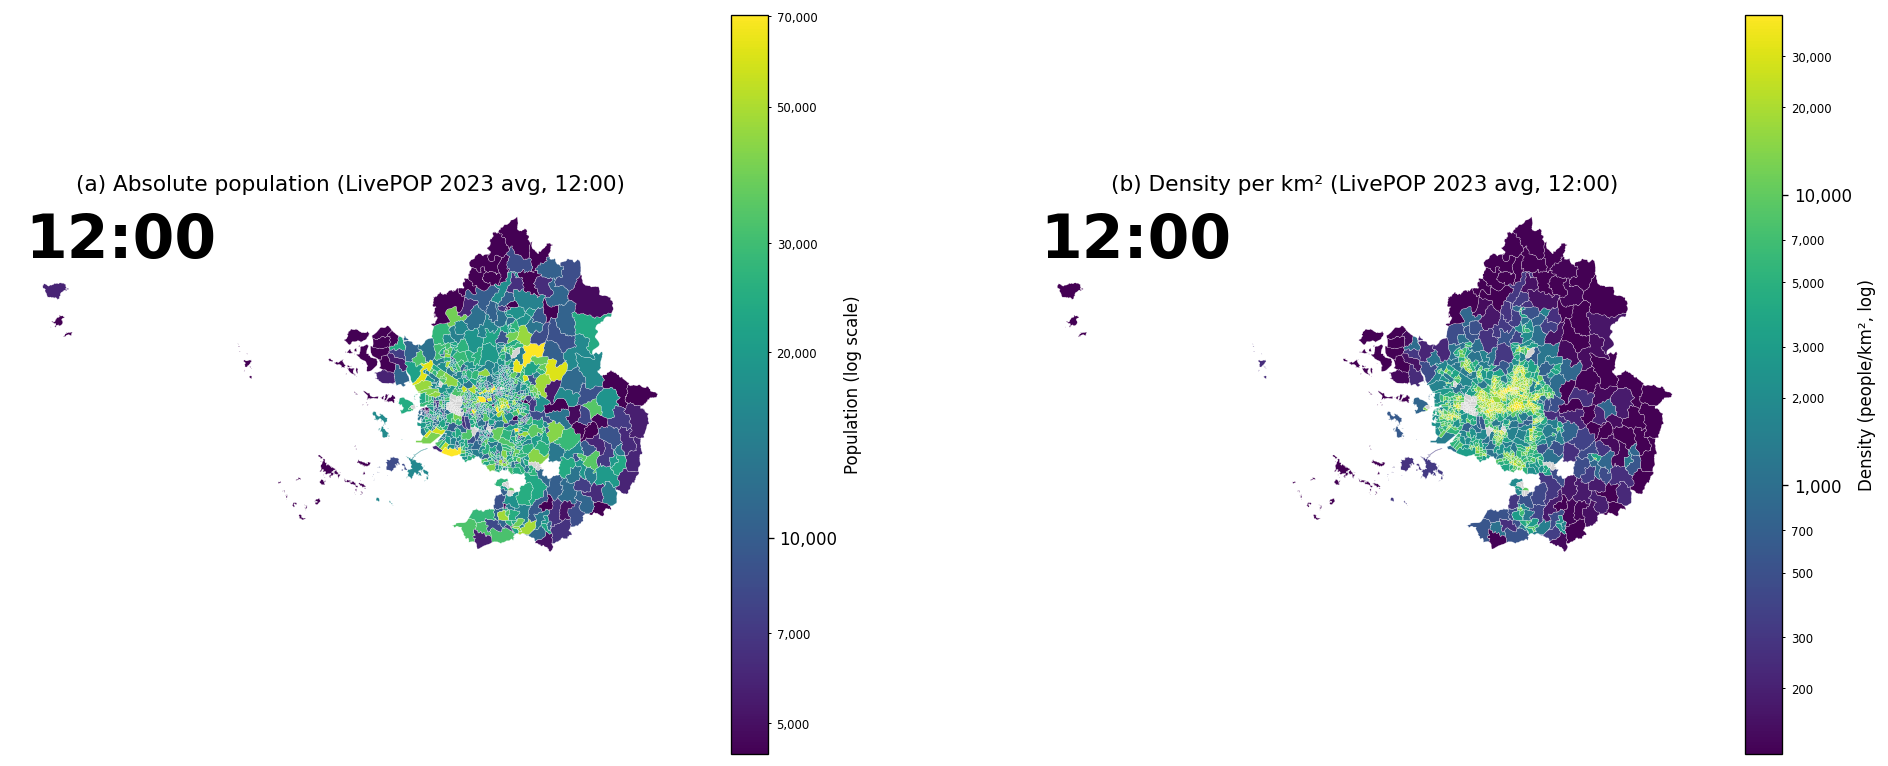

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(20, 10), dpi=120)
plot_hour(12, ax=axes[0], show_colorbar=True)
axes[0].set_title("(a) Absolute population (LivePOP 2023 avg, 12:00)", fontsize=13)
plot_hour_density(12, ax=axes[1], show_colorbar=True)
axes[1].set_title("(b) Density per km² (LivePOP 2023 avg, 12:00)", fontsize=13)
out_cmp = OUT_DIR_CMP / "comparison_12h.png"
fig.savefig(out_cmp, dpi=120, bbox_inches="tight")
print("wrote", out_cmp)
plt.show()